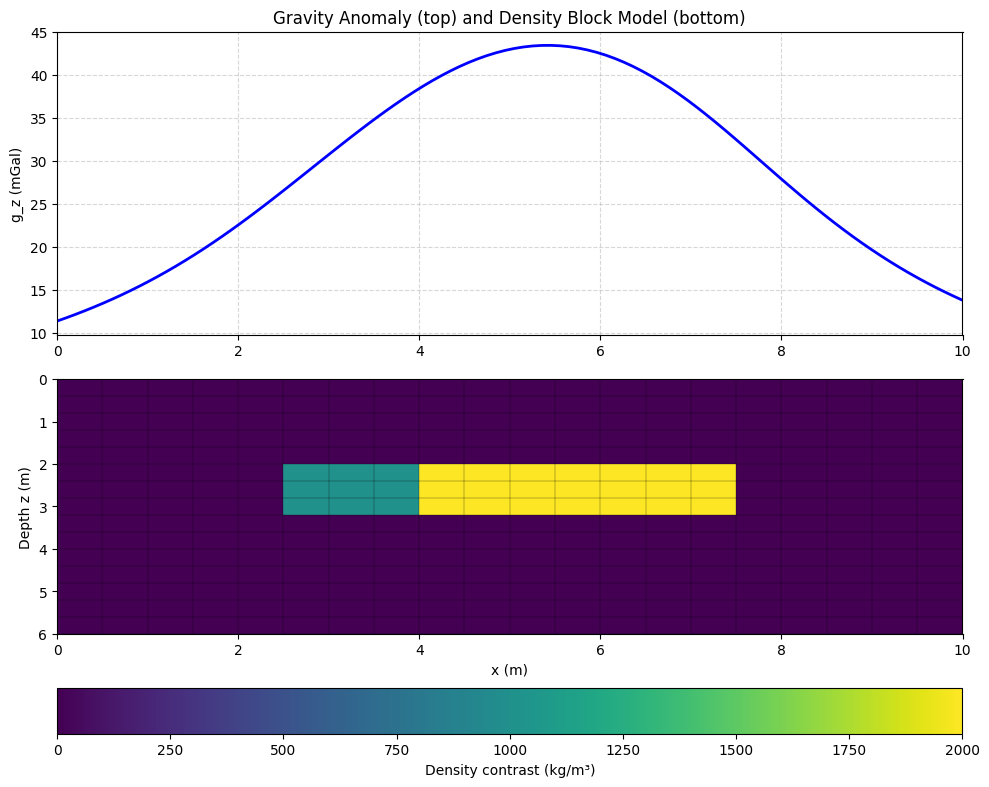

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Fungsi GPOLY: perhitungan gaya berat vertikal dari poligon 2D
# =========================================================
def gpoly(x0, z0, xcorn, zcorn, rho):
    xcorn = np.asarray(xcorn, dtype=float)
    zcorn = np.asarray(zcorn, dtype=float)
    n = len(xcorn)

    gamma = 6.67e-11      # gravitational constant (SI)
    si2mg = 1.0e5         # m/s^2 -> mGal
    km2m  = 1.0e3         # km -> m

    s = 0.0
    for i in range(n):
        j = (i + 1) % n
        x1 = xcorn[i] - x0
        z1 = zcorn[i] - z0
        x2 = xcorn[j] - x0
        z2 = zcorn[j] - z0

        r1sq = x1**2 + z1**2
        r2sq = x2**2 + z2**2
        if r1sq == 0 or r2sq == 0:
            continue

        denom = z2 - z1
        if denom == 0.0:
            denom = 1.0e-6

        alpha = (x2 - x1) / denom
        beta  = (x1 * z2 - x2 * z1) / denom
        factor = beta / (1.0 + alpha**2)

        term1 = 0.5 * (np.log(r2sq) - np.log(r1sq))
        term2 = np.arctan2(z2, x2) - np.arctan2(z1, x1)
        s += factor * (term1 - alpha * term2)

    g = 2.0 * rho * gamma * s * si2mg * km2m
    return g

# =========================================================
# Buat model blok 5 x 3
# =========================================================
nx, nz = 20, 15 #banyaknya blok
xmax, zmax = 10.0, 6.0  # km
x_edges = np.linspace(0, xmax, nx+1)
z_edges = np.linspace(0, zmax, nz+1)

rho_model = np.zeros((nz, nx))
# Contoh anomali: kotak di tengah
rho_model[5:8, 8:15] = 2000.0
rho_model[5:8, 5:8] = 1000.0

# =========================================================
# Hitung respon gravitasi
# =========================================================
x_profile = np.linspace(0, 10.0, 100)
z_obs = 0.0
g_profile = np.zeros_like(x_profile)

nonzero_cells = np.argwhere(rho_model != 0.0)
for (iz, ix) in nonzero_cells:
    rho = rho_model[iz, ix]
    x1, x2 = x_edges[ix], x_edges[ix+1]
    z1, z2 = z_edges[iz], z_edges[iz+1]
    xcorn = [x1, x2, x2, x1]
    zcorn = [z1, z1, z2, z2]
    g_profile += np.array([gpoly(x, z_obs, xcorn, zcorn, rho)for x in x_profile])

# =========================================================
# Plot gabungan
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios":[1,1.2]})

# Kurva gravitasi
ax1 = axes[0]
ax1.plot(x_profile, g_profile, "b-", linewidth=2)
ax1.set_ylabel("g_z (mGal)")
ax1.set_title("Gravity Anomaly (top) and Density Block Model (bottom)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.set_xlim(x_profile.min(), x_profile.max())

# Blok model
ax2 = axes[1]
X, Z = np.meshgrid(x_edges, z_edges)
c = ax2.pcolormesh(X, Z, rho_model, cmap="viridis", shading="auto")
ax2.set_aspect("auto")
ax2.invert_yaxis()
ax2.set_xlabel("x (m)")
ax2.set_ylabel("Depth z (m)")
plt.colorbar(c, ax=ax2, orientation='horizontal', label="Density contrast (kg/m³)")

# Tambahkan garis grid blok
for xe in x_edges:
    ax2.vlines(xe, z_edges.min(), z_edges.max(), colors="k", linewidth=0.2)
for ze in z_edges:
    ax2.hlines(ze, x_edges.min(), x_edges.max(), colors="k", linewidth=0.2)

plt.tight_layout()
plt.show()